# Find the optimal alpha value
March 11, 2024

**edit: Post, fixing the smoothing of the i, t, and b branches separately. And CLOCCS 100k runs**

Now that the CLOCCS parameters are correct and the two replicates are producing concordante deconvolution results. We now look at the daughter specific genes, DSE1-4 to determine the alpha value that is required, per Xin:

"We calibrated the duration of the attachment period to be the smallest duration such that the decon- volved transcription profiles of all four genes are primarily within DG1"

Iterate through possible values of alpha and compute the proportion of gene expression DG1 over the total gene expression. Then for each gene for each replicate plot the alpha values against these computed proportions. The alpha value for each replicate will be the peak DG1 proportion with the lowest alpha. For simplicity we will take the mean across these four genes.


In [3]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
from src.alpha_search import main

combined_dg1_df = main()


Computing 50 alpha values for DSE1...Done in 00:05:20.72
Computing 50 alpha values for DSE2...Done in 00:10:39.38
Computing 50 alpha values for DSE3...Done in 00:15:55.06
Computing 50 alpha values for DSE4...Done in 00:21:10.97
Computing 50 alpha values for DSE1...Done in 00:26:24.03
Computing 50 alpha values for DSE2...Done in 00:31:37.52
Computing 50 alpha values for DSE3...Done in 00:36:54.30
Computing 50 alpha values for DSE4...Done in 00:42:17.09
Save to: output/dg1_alpha_search_0_50_1.csv


In [5]:
combined_dg1_df.tail()

,alpha,prop_dg1,gamma,rn,sn,f,gene,replicate
45,45,0.259016,0.00109,0.018962,12.888764,"[17.934882304191103, 17.898171567969605, 17.82...",DSE4,2
46,46,0.272267,0.00064,0.013378,14.320684,"[17.54535543978524, 17.526990906373985, 17.490...",DSE4,2
47,47,0.272836,0.00055,0.012502,14.694584,"[17.577775072080907, 17.56242818288813, 17.532...",DSE4,2
48,48,0.270440,0.00055,0.012338,14.895397,"[17.758152992260914, 17.742746574719142, 17.71...",DSE4,2
49,49,0.266408,0.00055,0.012271,14.996741,"[17.96666456729239, 17.950926171651425, 17.919...",DSE4,2


In [6]:
combined_dg1_df.head()

,alpha,prop_dg1,gamma,rn,sn,f,gene,replicate
0,0,0.228476,0.00100,0.019766,8.395431,"[17.212758495264588, 17.196044290282252, 17.16...",DSE1,1
1,1,0.230681,0.00091,0.016856,8.597501,"[17.2121252821144, 17.1948559763973, 17.160501...",DSE1,1
2,2,0.229657,0.00100,0.018430,8.380394,"[17.15638484891989, 17.140814095748254, 17.109...",DSE1,1
3,3,0.231474,0.00100,0.017815,8.378678,"[17.113590549046343, 17.098025837828743, 17.06...",DSE1,1
4,4,0.235063,0.00091,0.015534,8.382669,"[17.066159720028907, 17.050260089877035, 17.01...",DSE1,1


In [7]:
from src.alpha_search import compute_peak_dg1s

peak_locs_df = compute_peak_dg1s(combined_dg1_df)
peak_locs_df

,alpha,prop_dg1,gamma,rn,sn,f,gene,replicate,peak_dg1
0,0,0.228476,0.00100,0.019766,8.395431,"[17.212758495264588, 17.196044290282252, 17.16...",DSE1,1,0
1,1,0.230681,0.00091,0.016856,8.597501,"[17.2121252821144, 17.1948559763973, 17.160501...",DSE1,1,0
2,2,0.229657,0.00100,0.018430,8.380394,"[17.15638484891989, 17.140814095748254, 17.109...",DSE1,1,0
3,3,0.231474,0.00100,0.017815,8.378678,"[17.113590549046343, 17.098025837828743, 17.06...",DSE1,1,4
4,4,0.235063,0.00091,0.015534,8.382669,"[17.066159720028907, 17.050260089877035, 17.01...",DSE1,1,8
...,...,...,...,...,...,...,...,...,...
395,45,0.259016,0.00109,0.018962,12.888764,"[17.934882304191103, 17.898171567969605, 17.82...",DSE4,2,32
396,46,0.272267,0.00064,0.013378,14.320684,"[17.54535543978524, 17.526990906373985, 17.490...",DSE4,2,33
397,47,0.272836,0.00055,0.012502,14.694584,"[17.577775072080907, 17.56242818288813, 17.532...",DSE4,2,33
398,48,0.270440,0.00055,0.012338,14.895397,"[17.758152992260914, 17.742746574719142, 17.71...",DSE4,2,33


In [8]:
outdir = 'output/alpha_search/'

In [9]:
from src.alpha_search import plot_DG1_genes_alpha_curves

fig = plot_DG1_genes_alpha_curves(peak_locs_df, 1, 29, normalize=True,
                                 genes=['DSE1', 'DSE2', 'DSE3', 'DSE4'])
plt.savefig(f"{outdir}/rep{1}_dg1_{29}_dse_genes_normalized.png", dpi=150)
plt.close(fig)


fig = plot_DG1_genes_alpha_curves(peak_locs_df, 2, 19, normalize=True,
                                 genes=['DSE1', 'DSE2', 'DSE3', 'DSE4'])
plt.savefig(f"{outdir}/rep{2}_dg1_{19}_dse_genes_normalized.png", dpi=150)
plt.close(fig)

In [10]:
from src.alpha_search import plot_DG1_genes_alpha_curves

for replicate in [1, 2]:
    for alpha in combined_dg1_df.alpha.unique():
        fig = plot_DG1_genes_alpha_curves(peak_locs_df, replicate, alpha, normalize=False)
        plt.savefig(f"{outdir}/rep{replicate}_dg1_{alpha}_unnormalized.png", dpi=150)
        plt.close(fig)


In [11]:
def get_gene_alphas(dat, gene_name, replicate):
    dat = combined_dg1_df.set_index(['replicate', 'gene'])
    gene_alphas = dat.loc[replicate].loc[gene_name]
    gene_alphas = gene_alphas.reset_index(drop=True).set_index('alpha')
    return gene_alphas
    
def get_peak_alpha_location(dat, gene_name, replicate):
    gene_alphas = get_gene_alphas(dat, gene_name, replicate)
    max_alpha = gene_alphas[['prop_dg1']].idxmax()[0]
    return gene_alphas.prop_dg1, max_alpha

In [12]:
genes = combined_dg1_df.gene.unique()

In [13]:
dse_genes = ['DSE1', 'DSE2', 'DSE3', 'DSE4']

Replicate 1
  DSE1, alpha=24
  DSE2, alpha=24
  DSE3, alpha=32
  DSE4, alpha=33
Mean alpha=28.25

Replicate 2
  DSE1, alpha=18
  DSE2, alpha=19
  DSE3, alpha=26
  DSE4, alpha=24
Mean alpha=21.75


Text(0.5, 1.0, 'Replicate 2')

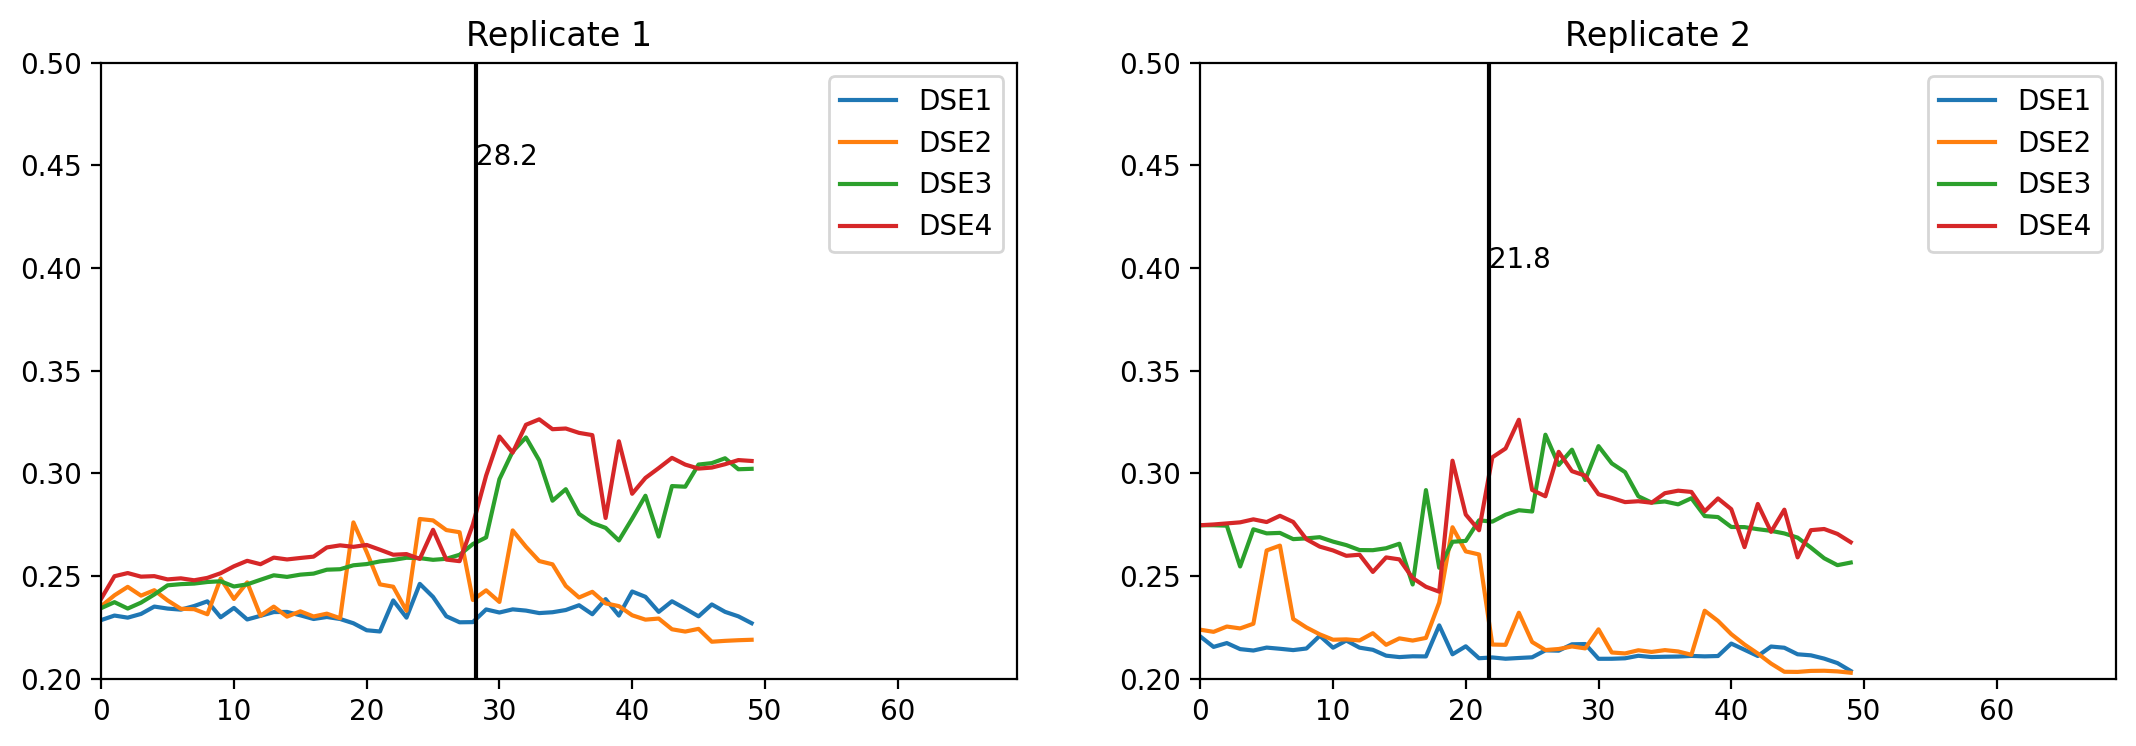

In [14]:
plt.figure(figsize=(13, 4))

plt.subplot(1, 2, 1)
print("Replicate 1")
sum_alpha = 0

for gene in dse_genes:
    gene_alphas, alpha = get_peak_alpha_location(combined_dg1_df, gene, 1)
    sum_alpha += alpha
    plt.plot(gene_alphas, label=gene)
    print(f"  {gene}, alpha={alpha}")
plt.legend()
mean_alpha = sum_alpha/len(dse_genes)
plt.axvline(mean_alpha, c='black')
plt.text(mean_alpha, 0.45, f"{mean_alpha:.1f}")
plt.title("Replicate 1")
plt.xlim(0, 69)
plt.ylim(0.2, 0.5)
print(f"Mean alpha={mean_alpha}")
print()

plt.subplot(1, 2, 2)
print("Replicate 2")
sum_alpha = 0
for gene in dse_genes:
    gene_alphas, alpha = get_peak_alpha_location(combined_dg1_df, gene, 2)
    plt.plot(gene_alphas, label=gene)
    sum_alpha += alpha
    print(f"  {gene}, alpha={alpha}")
plt.legend()
mean_alpha = sum_alpha/len(dse_genes)
plt.axvline(mean_alpha, c='black')
plt.text(mean_alpha, 0.4, f"{mean_alpha:.1f}")
plt.xlim(0, 69)
plt.ylim(0.2, 0.5)
print(f"Mean alpha={mean_alpha}")
plt.title("Replicate 2")


In [27]:
from src.dynamic_config_alpha import create_dynamic_alpha_config
from src.model import Model

gene_name = "DSE2"
config = create_dynamic_alpha_config(alpha=28, replicate=1)
model = Model(config, gene_name)
model.deconvolve_find_optimal_gamma()

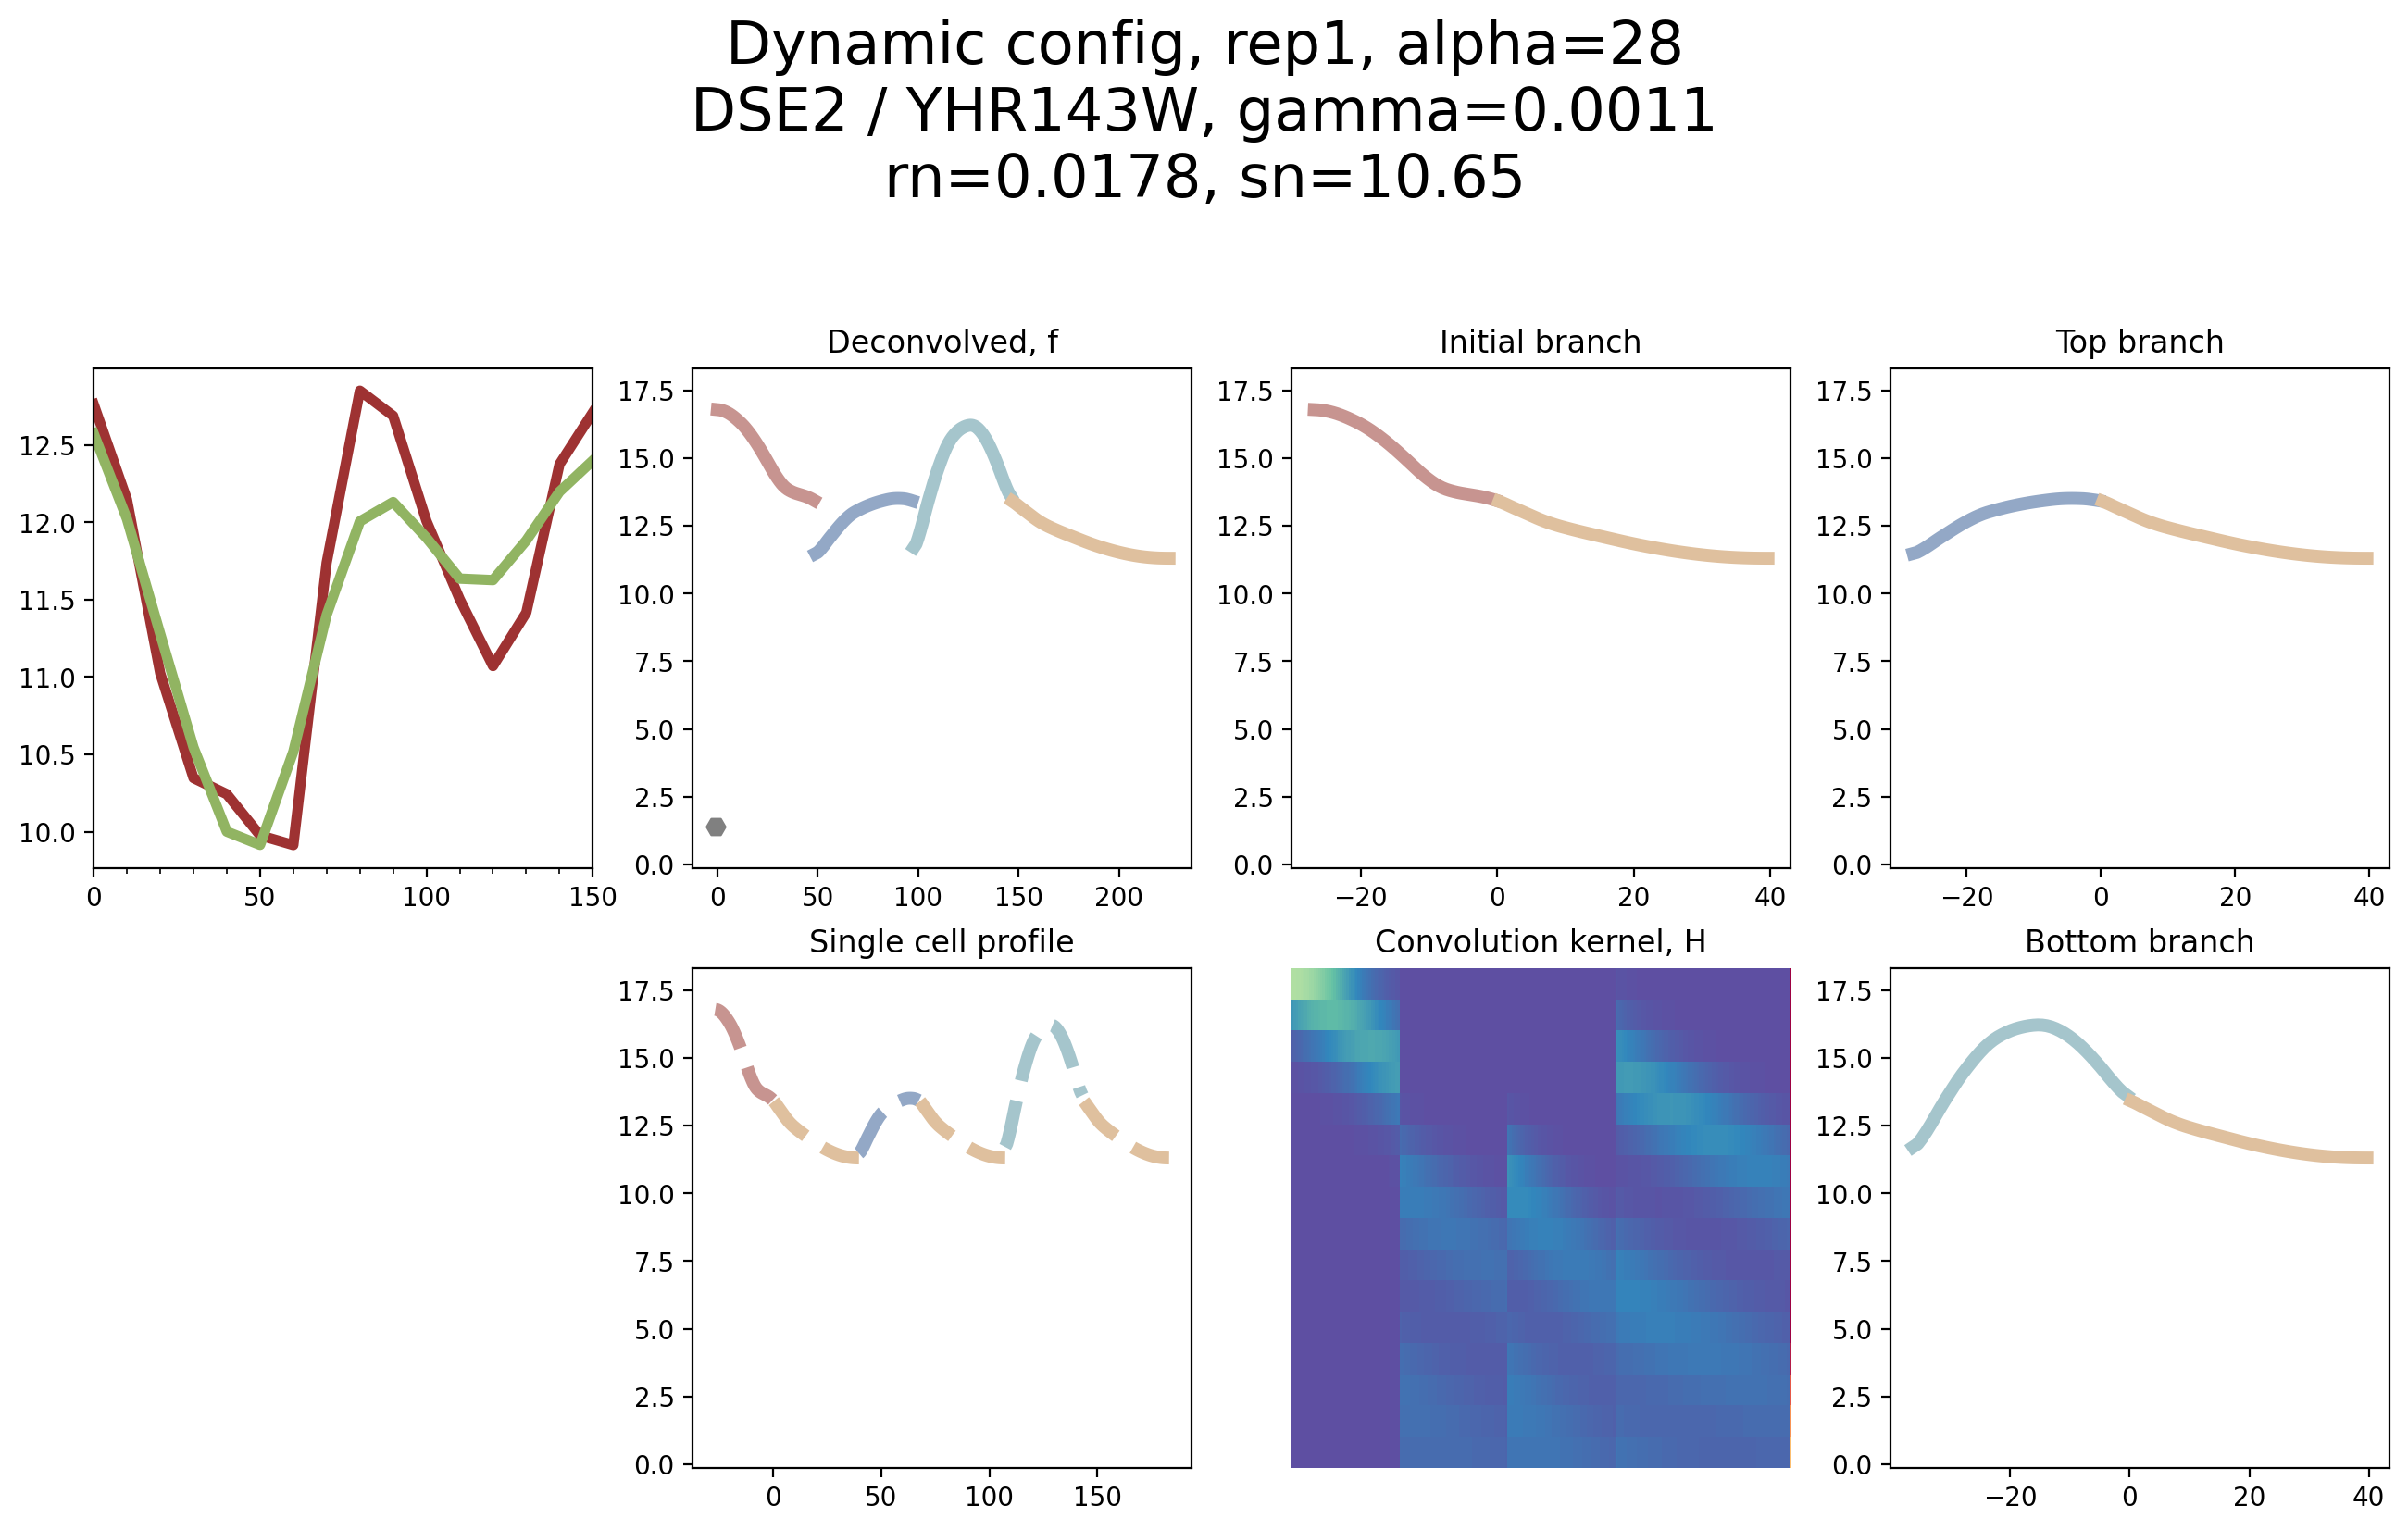

In [28]:
fig = model.plot_deconvolved_gene()